# Atividade 1 – Segmentação e Visão Computacional


Seções:
- Parte I: Limiarização (manual, Otsu, adaptativa)
- Parte II: Espaços de cor (RGB, HSV, L*a*b*)
- Parte III: Agrupamento k-means no plano a*b*
- Parte IV: Morfologia e refino das máscaras
- Análise comparativa final


In [73]:
from pathlib import Path
import sys

import numpy as np
import cv2
from skimage import color, data
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

sys.path.append("../src")
from otsu import otsu_threshold

plt.rcParams["figure.figsize"] = (6, 4)

ROOT = Path().resolve().parent
DATA_DIR = ROOT / "images" / "input"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ROOT / "images" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

coins_path = DATA_DIR / "coins.png"
if not coins_path.exists():
    coins = data.coins()
    cv2.imwrite(str(coins_path), coins)
    print("Imagem salva em", coins_path)
else:
    print("Imagem já existe, pulando.")

Imagem já existe, pulando.


## Carregamento de imagem

Aqui ficam funções auxiliares para leitura e exibição das imagens da pasta `images/input`.


In [74]:
# carregamento da imagem RGB da pasta images/input
def load_rgb(name: str):
    """Carrega uma imagem RGB da pasta `images/input`."""
    path = DATA_DIR / name
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Imagem não encontrada: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

# show imagens lado a lado
def show_side_by_side(images, titles):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [75]:
def analisar_otsu(nome_arquivo, titulo):
    img_rgb = load_rgb(nome_arquivo)
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    t = otsu_threshold(img_gray)

    mask = (img_gray >= t).astype(np.uint8) * 255

    plt.hist(img_gray.flatten(), bins=256, range=(0, 256), color='gray')
    plt.axvline(t, color='red', linestyle='--', label=f'T = {t}')
    plt.title(f"Histograma — {titulo}")
    plt.xlabel("Intensidade")
    plt.ylabel("Contagem")
    plt.legend()
    plt.show()

    show_side_by_side(
        [img_rgb, img_gray, mask],
        ["Original", "Tons de cinza", f"Máscara (Otsu, T={t})"]
    )

## Parte I – Limiarização Manual

Ponto de partida da segmentação: converter a imagem para escala de cinza e aplicar um limiar fixo T escolhido manualmente. O objetivo é entender o mecanismo básico e observar suas limitações antes de avançar para métodos automáticos.

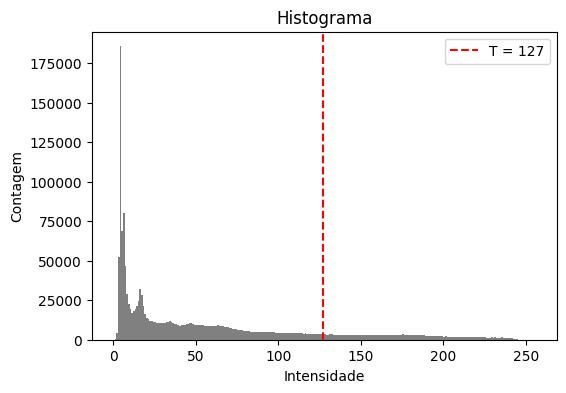

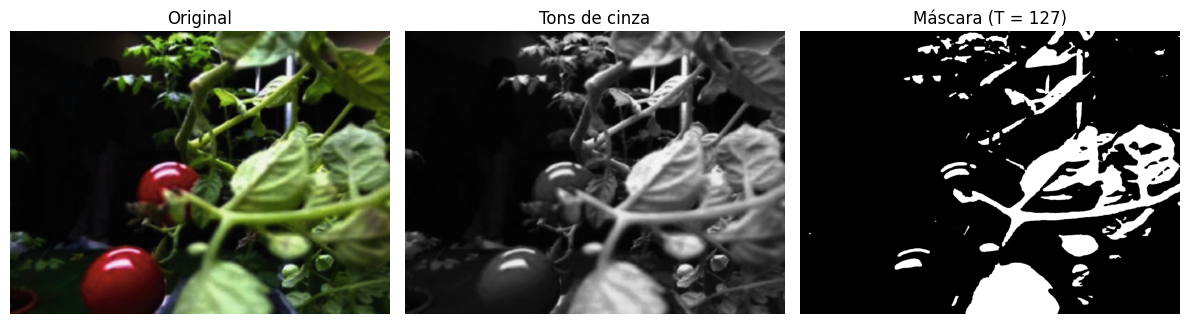

In [76]:
# Carrega a imagem colorida e converte para escala de cinza
img_rgb = load_rgb("tomates-corke.png")
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Limiar fixo escolhido manualmente — pixels >= T viram branco, demais preto
T = 127
mask = (img_gray >= T).astype(np.uint8) * 255

# Histograma da imagem em cinza com marcação visual do limiar escolhido
plt.hist(img_gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.axvline(T, color='red', linestyle='--', label=f'T = {T}')
plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Contagem")
plt.legend()
plt.show()

# Comparação visual: original, cinza e máscara binária
show_side_by_side(
    [img_rgb, img_gray, mask],
    ["Original", "Tons de cinza", f"Máscara (T = {T})"]
)

## Limiarização Método Otsu

Este bloco demonstra como chamar a função `otsu_threshold` (a ser implementada em `src/otsu.py`).


Limiar de Otsu: 90


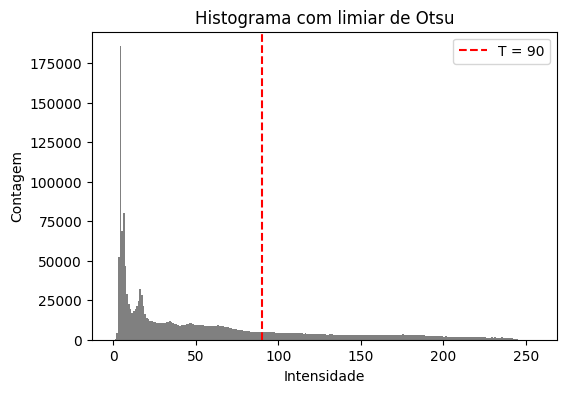

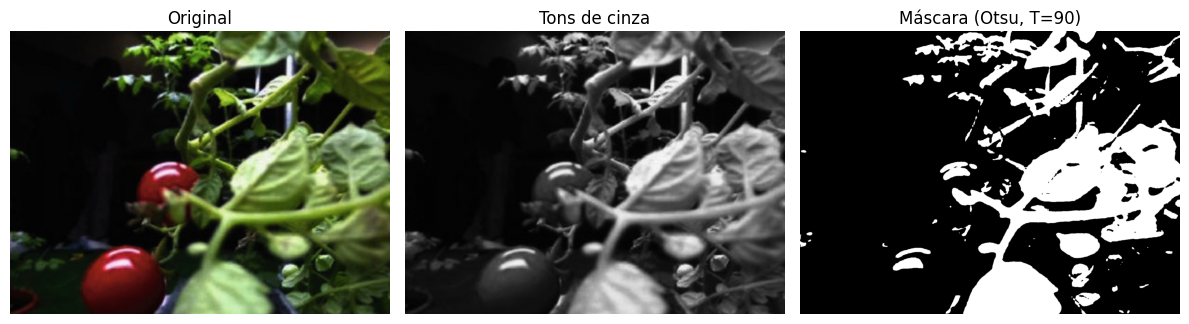

In [77]:
img_rgb = load_rgb("tomates-corke.png")  # ajuste o nome do arquivo se necessário
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

t = otsu_threshold(img_gray)
print("Limiar de Otsu:", t)

mask = (img_gray >= t).astype(np.uint8) * 255


# Histograma com o limiar de Otsu marcado
plt.hist(img_gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.axvline(t, color='red', linestyle='--', label=f'T = {t}')
plt.title("Histograma com limiar de Otsu")
plt.xlabel("Intensidade")
plt.ylabel("Contagem")
plt.legend()
plt.show()

show_side_by_side(
    [img_rgb, img_gray, mask],
    ["Original", "Tons de cinza", f"Máscara (Otsu, T={t})"]
)

### Comparativo Otsu manual, Otsu OpenCV e Otsu scikit-image 

T manual:       90
T OpenCV:       89.0
T scikit-image: 89


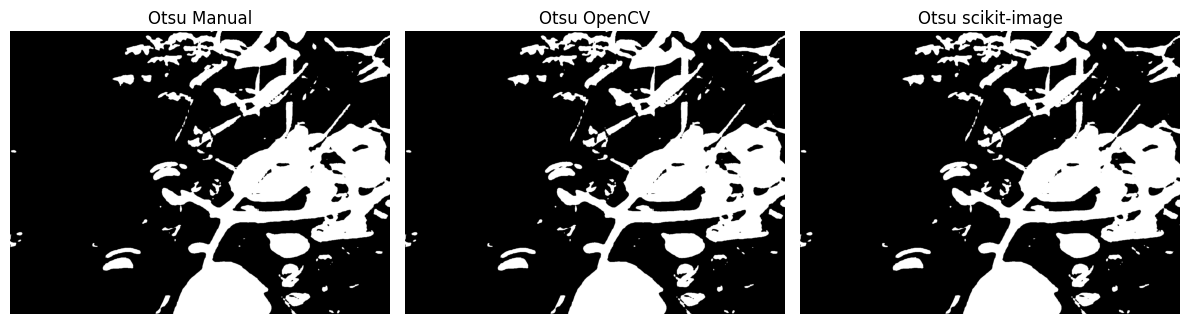

In [78]:
t_manual = otsu_threshold(img_gray)
t_cv, mask_cv = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_ski = threshold_otsu(img_gray)
mask_ski = (img_gray >= t_ski).astype(np.uint8) * 255
mask_manual = (img_gray >= t_manual).astype(np.uint8) * 255

print(f"T manual:       {t_manual}")
print(f"T OpenCV:       {t_cv}")
print(f"T scikit-image: {t_ski}")

show_side_by_side(
    [mask_manual, mask_cv, mask_ski],
    ["Otsu Manual", "Otsu OpenCV", "Otsu scikit-image"]
)

### Casos de sucesso e falha

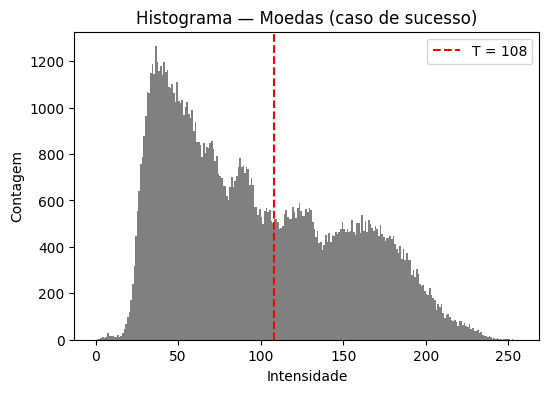

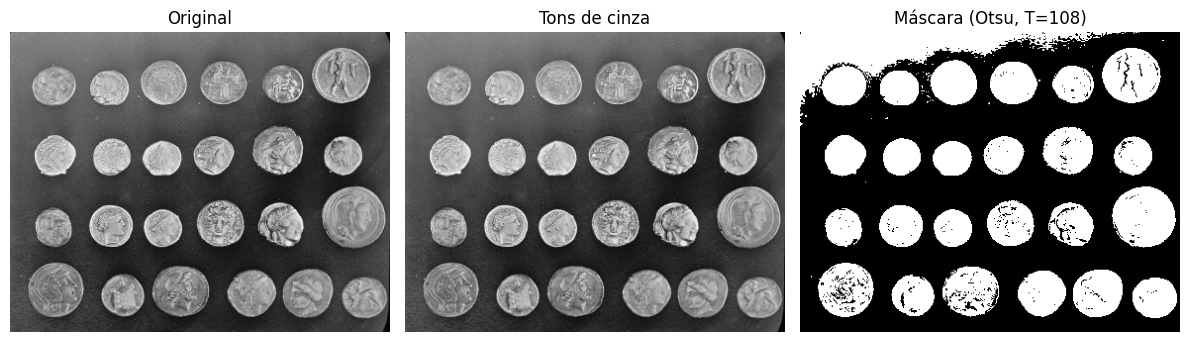

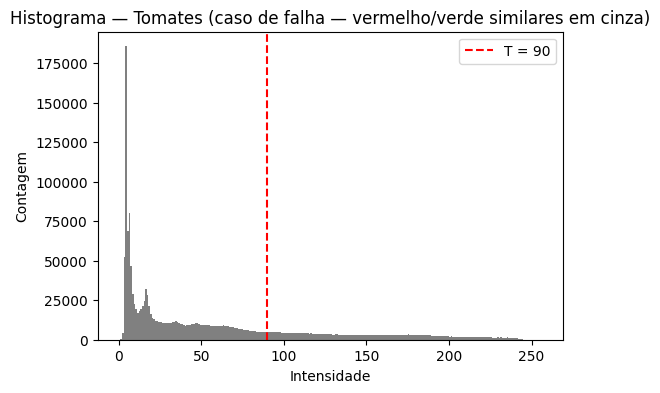

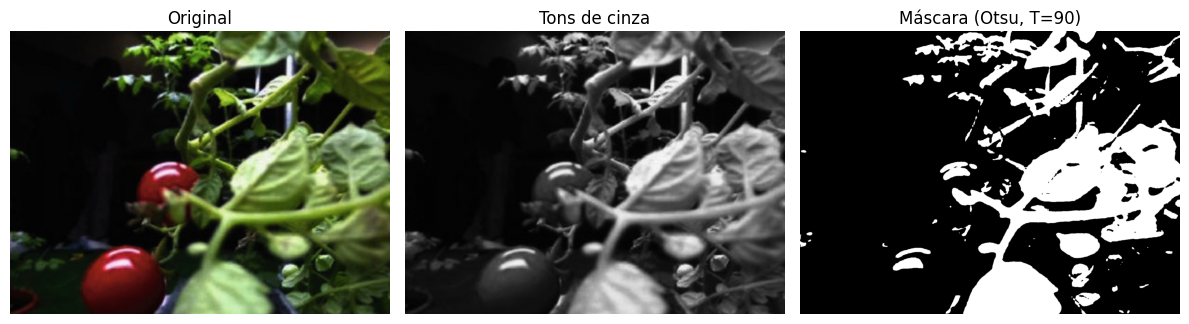

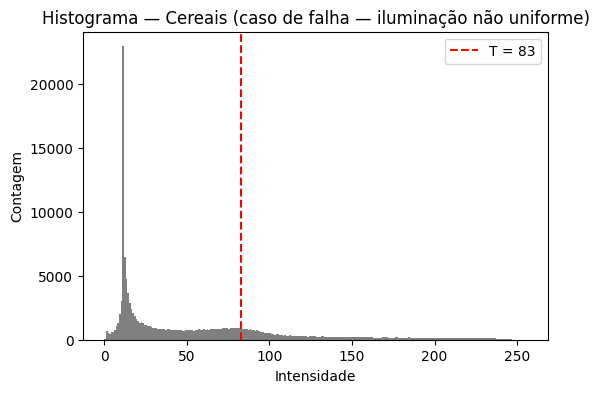

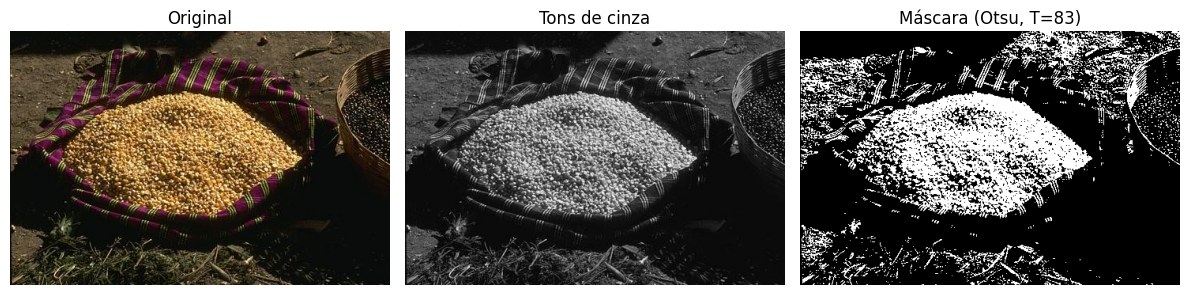

In [79]:
analisar_otsu("coins.png", "Moedas (caso de sucesso)")
analisar_otsu("tomates-corke.png", "Tomates (caso de falha — vermelho/verde similares em cinza)")
analisar_otsu("imagem-cereais-corke.png", "Cereais (caso de falha — iluminação não uniforme)")

## Limiarização Adaptativa

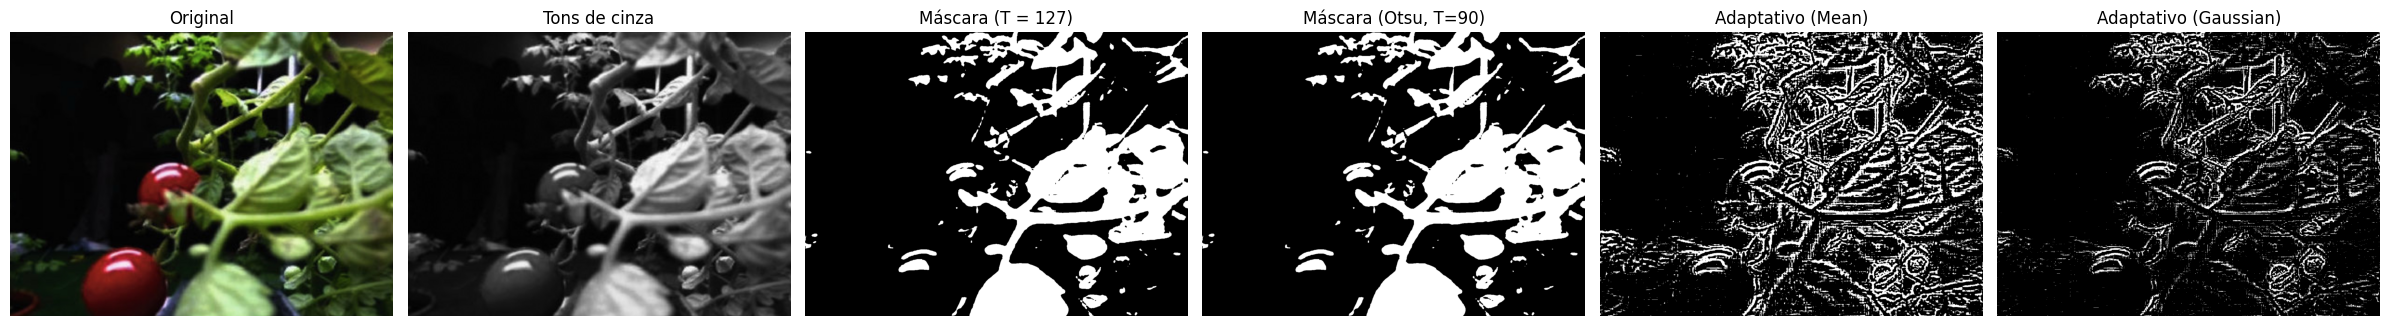

In [80]:
img_rgb = load_rgb("tomates-corke.png")  # ajuste o nome do arquivo se necessário
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

#cv2.adaptiveThreshold(img_gray, maxValue, adaptiveMethod, thresholdType, blockSize, C)
mask_mean = cv2.adaptiveThreshold( img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 11, 2)
mask_gaussian = cv2.adaptiveThreshold( img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

show_side_by_side(
    [img_rgb, img_gray, mask, mask, mask_mean, mask_gaussian],
    ["Original", "Tons de cinza",f"Máscara (T = {T})", f"Máscara (Otsu, T={t})", "Adaptativo (Mean)", "Adaptativo (Gaussian)"]
)